# ADA final exam (Fall 2023)

This exam consists of 2 parts. Parts are independent from each other.

## Dataset


"Friends" is an American television sitcom that originally aired on NBC from September 22, 1994, to May 6, 2004. Created by David Crane and Marta Kauffman, the show gained immense popularity and has since become a classic in the world of television. The series is set in New York City and revolves around a group of six friends: Ross Geller (David Schwimmer), Rachel Green (Jennifer Aniston), Monica Geller (Courteney Cox), Chandler Bing (Matthew Perry), Joey Tribbiani (Matt LeBlanc), and Phoebe Buffay (Lisa Kudrow). The show explores their personal and professional lives as they navigate the ups and downs of relationships, careers, and the challenges of adulthood.

In this exam, we will use a dataset containing all the conversations that occurred over 10 seasons of Friends. We refer to each row in the dataset as an 'utterance." The data format of the dataset is as follows

- id: `<str>`, the index of the utterance in the format sAA_eBB_cCC_uDDD, where AA is the season number, BB is the episode number, CC is the scene/conversation number, and DDD is the number of the utterance in the scene (e.g. s01_e18_c05_u021).
- speaker: `<str>`, the speaker who made the utterance, e.g. Monica Geller
- conversation_id: `<str>`, the id of the first utterance in the conversation this utterance belongs. We assume conversations begin at the start of a new scene.
- reply_to: `<str>`, the id of the utterance to which this utterance replies. None if the utterance is the first in a conversation.
- text: `<str>`, the textual content of the utterance.


In [2]:
# First, let's import some required libraries!
import statsmodels.formula.api as smf
import pandas as pd
from collections import Counter
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import numpy as np


## Part 1: The one where you find the protagonist (60 pts)

A big debate among Friends fans is: who is the show's main character? In this task, your goal is to provide a data-driven answer to this question.


--- 

**1.1 —** Load the data from the jsonl file `exam1.jsonl` into a pandas dataframe. Then
 
 A. Calculate and display the number of distinct speakers in the dataframe.
 
 B. Calculate and display the number of conversations (see `conversation_id`).
 
 C. Remove all utterances from the dataframe where the `speaker` is "TRANSCRIPT_NOTE" or "#ALL#". Print the number of rows in the dataframe.
 
 D. Create additional columns corresponding to the season (`season`, e.g., season 1 should contain `s01`) and the episode (`episode`, e.g., episode 5 of season 4 should contain `s04_e05`) of each utterance. Print the season and the episode associated with utterance `s10_e18_c11_u019`.
 
 E. Create an additional column corresponding to the length of each utterance in terms of the number of characters (`length`). Print the length associated with utterance `s10_e18_c11_u019`.


In [3]:
df = pd.read_json('data/exam1.jsonl', lines=True)
# df[df['conversation_id'] == 's01_e01_c01_u001']
print("Shape original df:", df.shape)

# (A)
print('Number of speakers:',len(df['speaker'].unique()))

# (B)
print('Number of conversations:',len(df['conversation_id'].unique()))


# (C)
# print((df['speaker'] == "TRANSCRIPT_NOTE")[lambda x: x]) # only to print the True values
print("Any row with speaker = 'TRANSCRIPT_NOTE' or '#ALL#'?",((df['speaker'] == "TRANSCRIPT_NOTE") | (df['speaker'] ==  "#ALL#")).any()) # only to print if there is any True values
print("Num of rows to be remove:",((df['speaker'] == "TRANSCRIPT_NOTE") | (df['speaker'] ==  "#ALL#")).sum()) # counts the rows with only those values
df = df[(df['speaker'] != "TRANSCRIPT_NOTE") & (df['speaker'] !=  "#ALL#")]
print("Rows in the df without speaker = 'TRANSCRIPT_NOTE' or '#ALL#':", len(df))

# (D)
df['season'] = df['id'].str.slice(0, 3)
df['episode'] = df['id'].str.slice(0,7)
print(f's10_e18_c11_u019 season:{df[df['id']== 's10_e18_c11_u019']['season'].iloc[0]} , episode:{df[df['id']== 's10_e18_c11_u019']['episode'].iloc[0]}')

# (E)
# df['NumCharUtterance'] = df.groupby('conversation_id')['speaker'].transform('count')
df['length'] =  df["text"].apply(lambda x: len(x))
print(f's10_e18_c11_u019 length of text:{df[df['id']== 's10_e18_c11_u019']['length'].iloc[0]}')

df


Shape original df: (67373, 5)
Number of speakers: 700
Number of conversations: 3107
Any row with speaker = 'TRANSCRIPT_NOTE' or '#ALL#'? True
Num of rows to be remove: 6388
Rows in the df without speaker = 'TRANSCRIPT_NOTE' or '#ALL#': 60985
s10_e18_c11_u019 season:s10 , episode:s10_e18
s10_e18_c11_u019 length of text:17


,id,conversation_id,text,speaker,reply-to,season,episode,length
0,s01_e01_c01_u001,s01_e01_c01_u001,There's nothing to tell! He's just some guy I ...,Monica Geller,None,s01,s01_e01,56
1,s01_e01_c01_u002,s01_e01_c01_u001,"C'mon, you're going out with the guy! There's ...",Joey Tribbiani,s01_e01_c01_u001,s01,s01_e01,80
2,s01_e01_c01_u003,s01_e01_c01_u001,"All right Joey, be nice. So does he have a hum...",Chandler Bing,s01_e01_c01_u002,s01,s01_e01,72
3,s01_e01_c01_u004,s01_e01_c01_u001,"Wait, does he eat chalk?",Phoebe Buffay,s01_e01_c01_u003,s01,s01_e01,24
5,s01_e01_c01_u006,s01_e01_c01_u001,"Just, 'cause, I don't want her to go through w...",Phoebe Buffay,s01_e01_c01_u005,s01,s01_e01,79
...,...,...,...,...,...,...,...,...
67368,s10_e18_c11_u017,s10_e18_c11_u000,"Oh, it's gonna be okay.",Chandler Bing,s10_e18_c11_u016,s10,s10_e18,23
67369,s10_e18_c11_u018,s10_e18_c11_u000,Do you guys have to go to the new house right ...,Rachel Green,s10_e18_c11_u017,s10,s10_e18,77
67370,s10_e18_c11_u019,s10_e18_c11_u000,We got some time.,Monica Geller,s10_e18_c11_u018,s10,s10_e18,17
67371,s10_e18_c11_u020,s10_e18_c11_u000,"Okay, should we get some coffee?",Rachel Green,s10_e18_c11_u019,s10,s10_e18,32


**1.2** Next, you conduct some basic analyses:

 A. With `statsmodels`, fit a linear regression `length ~ C(season, Treatment(reference="s01"))`, where length is an integer and season is a categorical variable. Print the regression summary.
 
 B. /**Discuss:/** Considering the regression summary:
   - What does the intercept in this regression represent? 
   - What does the coefficient `C(season, Treatment(reference="s01"))[T.s09]` represent? 
   - Does the average utterance in season 9 contain significantly more characters than in season 1 at the 0.05 significance level? Justify with the regression summary **only**. 
   - Does the average utterance in season 10 contain significantly more characters than in season 1 at the 0.05 significance level? Justify with the regression summary  **only** .

 C. Argue visually (i.e., with a plot) that there are 6 main characters in the show.

In [4]:
#(A)
mod = smf.ols(formula='length ~ C(season, Treatment(reference="s01"))', data=df)
np.random.seed(2)
res = mod.fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                 length   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     8.058
Date:                Sat, 10 Jan 2026   Prob (F-statistic):           4.96e-12
Time:                        12:11:48   Log-Likelihood:            -3.2981e+05
No. Observations:               60985   AIC:                         6.596e+05
Df Residuals:                   60975   BIC:                         6.597e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

(B)
- The intercept represents the baseline s01. the avg leght of text if we are in s01. 
- the coef represent the addiotial length of text(compared to the baseline s01) that we have in s09 on average.
-  the coef is positive, so the it implies that on average s09 contains more text. It is significant at 0.05 significant level being th epvalue = 0.000
-  the coef is negative and not significant. we do not have enough eveidence to state what the question said. 

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Rachel Green'),
  Text(1, 0, 'Ross Geller'),
  Text(2, 0, 'Chandler Bing'),
  Text(3, 0, 'Monica Geller'),
  Text(4, 0, 'Joey Tribbiani'),
  Text(5, 0, 'Phoebe Buffay'),
  Text(6, 0, 'Mike Hannigan'),
  Text(7, 0, 'Richard Burke'),
  Text(8, 0, 'Janice Litman Goralnik'),
  Text(9, 0, 'Carol Willick')])

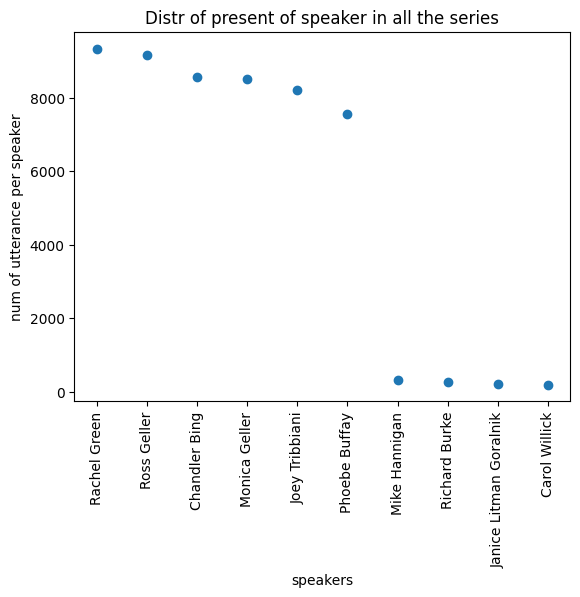

In [5]:
# (C)
freq = df['speaker'].value_counts()
top = freq.head(10)
plt.scatter(top.index,top.values)
plt.title("Distr of present of speaker in all the series")
plt.xlabel("speakers")
plt.ylabel("num of utterance per speaker")
plt.xticks(rotation=90)

--- 
**1.3 —** Using `networkx` 

A. Create a `MultiDiGraph` (directed graph with self loops and parallel edges) where:
- Each node $u$ is a character uniquely identified by the `speaker` field.
- There is an edge between nodes $u$ and $v$ if $u$ replied to $v$. If an utterance (a row in the dataframe) is said in reply to nobody, then it will not correspond to an edge. Each edge should contain two attributes. Each edge should have two attributes: `season` and `episode`.

B. Print the number of nodes and edges in your graph.

C. **/Discuss:/** Instead of using multi-edges, what would be another way in which you could capture the number of replies associated with each node pair?


In [6]:
# New df with the reply-to charcter instead of the id! 
df_m = pd.merge(df[['reply-to','speaker']],df, left_on='reply-to', right_on='id', how='left')
df_m = df_m.drop(columns='reply-to_x')
df_m.rename(columns={'speaker_x': 'reply-to-speaker','speaker_y': 'speaker'}, inplace=True)
df_m.dropna(subset='id')

,reply-to-speaker,id,conversation_id,text,speaker,reply-to_y,season,episode,length
1,Joey Tribbiani,s01_e01_c01_u001,s01_e01_c01_u001,There's nothing to tell! He's just some guy I ...,Monica Geller,None,s01,s01_e01,56.0
2,Chandler Bing,s01_e01_c01_u002,s01_e01_c01_u001,"C'mon, you're going out with the guy! There's ...",Joey Tribbiani,s01_e01_c01_u001,s01,s01_e01,80.0
3,Phoebe Buffay,s01_e01_c01_u003,s01_e01_c01_u001,"All right Joey, be nice. So does he have a hum...",Chandler Bing,s01_e01_c01_u002,s01,s01_e01,72.0
5,Monica Geller,s01_e01_c01_u006,s01_e01_c01_u001,"Just, 'cause, I don't want her to go through w...",Phoebe Buffay,s01_e01_c01_u005,s01,s01_e01,79.0
6,Chandler Bing,s01_e01_c01_u007,s01_e01_c01_u001,"Okay, everybody relax. This is not even a date...",Monica Geller,s01_e01_c01_u006,s01,s01_e01,109.0
...,...,...,...,...,...,...,...,...,...
60980,Chandler Bing,s10_e18_c11_u016,s10_e18_c11_u000,This is harder than I thought it would be.,Monica Geller,s10_e18_c11_u015,s10,s10_e18,42.0
60981,Rachel Green,s10_e18_c11_u017,s10_e18_c11_u000,"Oh, it's gonna be okay.",Chandler Bing,s10_e18_c11_u016,s10,s10_e18,23.0
60982,Monica Geller,s10_e18_c11_u018,s10_e18_c11_u000,Do you guys have to go to the new house right ...,Rachel Green,s10_e18_c11_u017,s10,s10_e18,77.0
60983,Rachel Green,s10_e18_c11_u019,s10_e18_c11_u000,We got some time.,Monica Geller,s10_e18_c11_u018,s10,s10_e18,17.0


In [7]:
# (A)
G = nx.from_pandas_edgelist(df_m, 'speaker', 'reply-to-speaker',  # turns a DataFrame of edges into a NetworkX graph.
                            edge_attr=["season", "episode"],
                            create_using=nx.MultiDiGraph())
# (B)
print(G)

# (C)
# We could use weighted edges. Each edge (u,v) could be associated with a weight corresponding to how many
# utterances u said in reply to v.

MultiDiGraph with 699 nodes and 60985 edges


---
With the graph ready, you set out to investigate who is the true protagonist of Friends.

Ignore the graph you generated previously and instead use the graph provided in `exam2.graphml`. Note that this graph may be slightly different from what you generated, but treat it as the ground truth. We provide you with code to load the graph below.


In [8]:
import networkx as nx

G = nx.read_graphml("./data/exam2.graphml")

---

**1.4 —** Using the provided MultiDiGraph $G$:

A. Calculate the out-degree of each node (also known as out-degree centrality). Please do not use the `nx.out_degree_centrality` function here, as it normalizes the degree. (E.g., if a node has 5 outgoing edges, it should have out-degree 5 according to your code.)

B. Calculate the PageRank centrality of each node in $G$. Use the default parameters.

C. Print both centrality metrics calculated above for the six main characters of Friends.

D. **/Discuss:/** According to the metrics, who is the most important character in Friends?

In [9]:
# (A)
out_d = [(n,id) for n, id in G.out_degree()]
df_centr = pd.DataFrame(out_d, columns=['speaker','out_degree']).set_index('speaker')

# (B)
pr = pd.Series(nx.pagerank(G))
df_centr['pagerank'] = pr
df_centr.head(6).sort_values(ascending=False, by='out_degree')

# (C)
# according to the out degreee Rachel Greeen having the highest out degreee and the highest pagerank score.

,out_degree,pagerank
speaker,,
Rachel Green,8470,0.126843
Ross Geller,8234,0.125611
Chandler Bing,7702,0.114535
Monica Geller,7621,0.113450
Joey Tribbiani,7395,0.112835
Phoebe Buffay,6797,0.102069


---

**1.5 —** **/True or false:/** Considering your answer in **1.4**, are the following statements true or false? Justify your answers. 

A. "If we inverted all  edges in the graph such that an edge $(u,v)$ becomes an edge $(v,u)$, the PageRank centrality would remain unchanged."

B. "If we removed all outgoing edges from Rachel Green, her PageRank centrality would remain unchanged."

C. "If a new node was introduced in the graph, with 1,000 outgoing edges towards each other node, but no incoming edge, it would have the highest PageRank centrality."


- A. False. Pangerank assess how importance is a node based on how many important nodes points to it. Of we invert the relationship between the characters, we modify the value of the pagerank. 
- B. False. Pagerank is affected by the out degree
- C. False. Pagerank depends mainly on incoming edge. This new node doesnt have incoming edge > it's not important.

---

**1.6 —** Next, you consider how these centrality metrics vary over the course of the seasons.

A. Calculate the PageRank and out-degree centrality of the 6 main characters per episode, i.e., for each episode, create a graph containing only the utterances of that episode and calculate the PageRank centrality for this new graph. Print the PageRank and the out-degree of Rachel Green for the first episode of the first season.

B. Considering the episode-level out-degree centrality of Phoebe Buffay in season 1 and in season 10, print the mean and the standard error of the mean.

C. Create a single plot with 10 inches of width and 4 inches of height. The plot should contain two panels, containing the average PageRank centrality per season of Rachel Green and Ross Geller (Panel A), and the average out-degree per season of Rachel Green and Ross Geller (Panel B). Show 95% confidence intervals in your plot (calculated over the episodes in each season).

D. **/Discuss:/** Does the plot support the hypothesis that Rachel was the show's protagonist in all 10 seasons? Explain why.

In [10]:
# (A)
G_all_ep = {}
G_all_ep_cent = {}
for ep in df_m['episode'].dropna().unique():
    ep_df = df_m[df_m['episode'] == ep].copy()
    subG = nx.from_pandas_edgelist(ep_df, 'speaker', 'reply-to-speaker',
                            edge_attr=["season", "episode"],
                            create_using=nx.MultiDiGraph())
    G_all_ep[ep] = subG

    out_d = [(n,id) for n, id in subG.out_degree()]
    df_centr_ep = pd.DataFrame(out_d, columns=['speaker','out_degree']).set_index('speaker')

    pr = pd.Series(nx.pagerank(subG))
    df_centr_ep['pagerank'] = pr
    G_all_ep_cent[ep] = df_centr_ep


print(f"Number of episode graphs stored: {len(G_all_ep)}")
print(f"Nodes in first episode graph: {G_all_ep['s01_e01'].nodes()}")

print(" ")

print("Rachel Green out-degree and pageranks score in s1 ep1:")   
print(G_all_ep_cent['s01_e01'].loc['Rachel Green'].head())


Number of episode graphs stored: 236
Nodes in first episode graph: ['Monica Geller', 'Joey Tribbiani', 'Chandler Bing', 'Phoebe Buffay', 'Ross Geller', 'Rachel Green', 'Waitress', 'Paul the Wine Guy', 'Priest On Tv', 'Franny', 'Customer']
 
Rachel Green out-degree and pageranks score in s1 ep1:
out_degree    40.000000
pagerank       0.172105
Name: Rachel Green, dtype: float64


In [11]:
# (B)
from scipy import stats

char = 'Phoebe Buffay'

s01 = df_m[df_m['season']=='s01']['episode'].dropna().unique()
s10 = df_m[df_m['season']=='s10']['episode'].dropna().unique()

out_degrees_s01 = [G_all_ep_cent[ep].loc[char, 'out_degree']
               for ep in s01
               if char in G_all_ep_cent[ep].index]

out_degrees_s10 = [G_all_ep_cent[ep].loc[char, 'out_degree']
               for ep in s10
               if char in G_all_ep_cent[ep].index]


print(f"Phoebe Buffay, s01: Mean out-degree {np.mean(out_degrees_s01)}, SEM out-degree: {stats.sem(out_degrees_s01)}") 
print(f"Phoebe Buffay, s10: Mean out-degree {np.mean(out_degrees_s10)}, SEM out-degree: {stats.sem(out_degrees_s10)}") 

Phoebe Buffay, s01: Mean out-degree 22.166666666666668, SEM out-degree: 2.205614268070668
Phoebe Buffay, s10: Mean out-degree 37.0, SEM out-degree: 2.9770362943772146


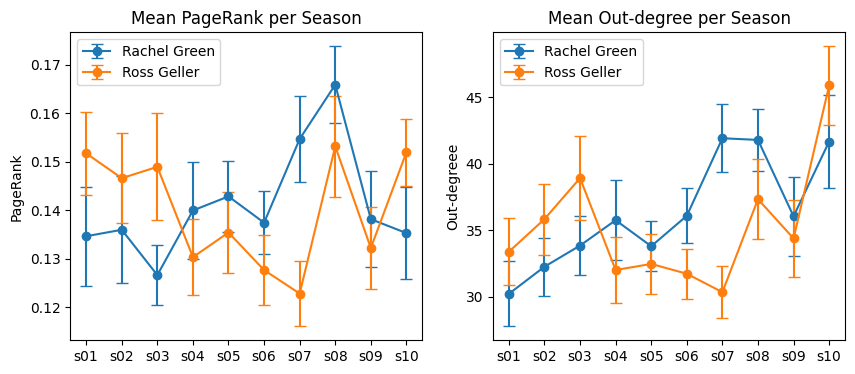

In [12]:
# (C)
seasons = df_m['season'].dropna().unique()

results_pr = {}
for char in ['Rachel Green', 'Ross Geller']:
    results_pr[char] = {}
    for s in seasons: 
        eps = df_m[df_m['season']== s ]['episode'].dropna().unique() 
        od_s = [G_all_ep_cent[ep].loc[char, 'pagerank'] 
                for ep in eps
                if char in G_all_ep_cent[ep].index] 
        mean_s = np.mean(od_s) 
        sem_s = stats.sem(od_s)
        results_pr[char][s] = {'mean': mean_s,'sem':sem_s}

results_od = {}
for char in ['Rachel Green', 'Ross Geller']:
    results_od[char] = {}
    for s in seasons: 
        eps = df_m[df_m['season']== s ]['episode'].dropna().unique() 
        od_s = [G_all_ep_cent[ep].loc[char, 'out_degree'] 
                for ep in eps
                if char in G_all_ep_cent[ep].index] 
        mean_s = np.mean(od_s) 
        sem_s = stats.sem(od_s)
        results_od[char][s] = {'mean': mean_s,'sem':sem_s}

fig, ax = plt.subplots(1,2,figsize=(10,4))

for char in ['Rachel Green', 'Ross Geller']:
    means = [results_pr[char][s]['mean'] for s in seasons]
    sems  = [results_pr[char][s]['sem']  for s in seasons]
    
    ax[0].errorbar(np.arange(len(seasons)), means, yerr=sems, marker='o', capsize=4, label=char)

ax[0].set_xticks(np.arange(len(seasons)))
ax[0].set_xticklabels(seasons)
ax[0].set_title("Mean PageRank per Season")
ax[0].set_ylabel("PageRank")
ax[0].legend()


for char in ['Rachel Green', 'Ross Geller']:
    means = [results_od[char][s]['mean'] for s in seasons]
    sems  = [results_od[char][s]['sem']  for s in seasons]
    
    ax[1].errorbar(np.arange(len(seasons)), means, yerr=sems, marker='o', capsize=4, label=char)

ax[1].set_xticks(np.arange(len(seasons)))
ax[1].set_xticklabels(seasons)
ax[1].set_title("Mean Out-degree per Season")
ax[1].set_ylabel("Out-degreee")
ax[1].legend()

---

**1.7 —** **/True or false:/** Considering your answer in **1.6** are the following statements true or false? Justify your answer. 


A. "In season 7, Rachel Green's episode-level PageRank and out-degree centrality are higher than Ross Geller's. This difference is statistically significant at the 0.05 significance level."

B. "Phoebe Buffay's out-degree grew between season 1 and season 10; this implies that other characters spoke less than her in season 10."

C. "Phoebe Buffay's PageRank was higher in season 10 than in season 1. This difference is statistically significant at the 0.05 significance level and suggests that the character gained importance over the course of the show."


Answers:
- A. True
- B. False. Maybe also other char spoke less
- C. True

## Part 2: The one about text similarity (40 pts)

Next, you investigate how unique characters are by analyzing what they said throughout the 10 seasons.

**2.1 —** Load the dataframe `exam3.jsonl`. This dataframe is similar to `exam1.jsonl`, except:

- It has an additional column called `tokens`, containing a sentence list. Each sentence is another list composed of tokens, e.g.,
`[['There', "'s", 'nothing', 'to', 'tell', '!'], ['He', "'s", 'just', 'some', 'guy', 'I', 'work', 'with', '!']]`.
- It has an additional column called `episode` containing a unique episode identifier.
- It only contains utterances by Phoebe, Rachel, Ross, Joey, Monica, or Chandler (the main characters).
 
Given this dataframe, you will create an episode-level word-frequency matrix for Chandler Bing, one of the main characters.

A. Create a list $L$ containing all distinct tokens uttered by Chandler Bing throughout the 10 seasons, sorted in ascending order. Print the 10 first and last elements of the list. 

B. Create a matrix $X$ with $m$ rows and $n$ columns, where: $n$ is the number of tokens in the list $L$ that you just created, and $m$ is the number of episodes (236). Each position $X_{i,j}$ in this matrix should contain the number of times the character uttered the word $j$ in episode $i$. Print how many times Chandler uttered the token `joey` in the first episode of the first season, as well as the shape of the matrix $X$.

C. Transform the matrix $X$ into a TF-IDF matrix $T$, combining the following formula (as seen in class):

$$\text{TF}(i,j) = \text{number of times the $j$-th word occurs in the $i$-th episode}$$

$$\text{IDF}(j) =  \log \frac{\text{number of episodes}}{\text{number of episodes in which the $j$-th word occurs}}$$

Print the value in the TF-IDF matrix corresponding to Chandler's utterance of the token `joey` in the first episode of the first season.

D. **/Discuss:/** Some of the tokens (e.g., `joey`) reference other characters. How may these tokens help a classifier predict which character uttered a sentence?

In [13]:
df2 = pd.read_json('data/exam3.jsonl', lines=True)
# tokens col is a list of list > you either explode twice or flatten:
df2["tokens_flat"] = df2["tokens"].apply(lambda xss: [x for xs in xss for x in xs])
df2.head(3)

,id,conversation_id,text,speaker,reply-to,tokens,episode,tokens_flat
0,s01_e01_c01_u001,s01_e01_c01_u001,There's nothing to tell! He's just some guy I ...,Monica Geller,None,"[[there, 's, nothing, to, tell, !], [he, 's, j...",s01_e01,"[there, 's, nothing, to, tell, !, he, 's, just..."
1,s01_e01_c01_u002,s01_e01_c01_u001,"C'mon, you're going out with the guy! There's ...",Joey Tribbiani,s01_e01_c01_u001,"[[c'mon, ,, you, 're, going, out, with, the, g...",s01_e01,"[c'mon, ,, you, 're, going, out, with, the, gu..."
2,s01_e01_c01_u003,s01_e01_c01_u001,"All right Joey, be nice. So does he have a hum...",Chandler Bing,s01_e01_c01_u002,"[[all, right, joey, ,, be, nice, .], [so, does...",s01_e01,"[all, right, joey, ,, be, nice, ., so, does, h..."


In [14]:
# (A)
df2_chandler = df2[df2['speaker'] == 'Chandler Bing']
# chandler_w = set(" ".join(df2_chandler['tokens']).split()) # set unique word only
# this was not working cause join was expected strings, not a list of tokens

chandler_w = {token 
              for utterance in df2_chandler['tokens']
              for sentence in utterance
              for token in sentence} 
# {} remove already duplicates 
# 'tokens' > column 
# └── utterance
#     ├── sentence
#     │   ├── word
#     │   ├── word

L= sorted(chandler_w) # the set {} is not ordered, but unique, but a list [] is ordered!

print("Chandler unique words:",L)
print(f'Chandler first 10 words:{L[:10]}')
print(f'Last 10: {L[-10:]}')

Chandler unique words: ['!', '!!', '!!!', '!!!!', '!!!!!', '!!!!!!!', '!..', '!...', '!?', '"', '$', '%', '&', "'", "'75", "'76", "'77", "'79", "'cause", "'d", "'joincidence", "'know", "'ll", "'m", "'re", "'s", "'s-", "'ve", '(', ')', '*', ',', '-', '--', '.', '..', '...', '...!', '...!?', '....', '.....', '......', '.......', '........', '...?', '...?!', '..?', '/', '0.', '007', '1', '1,000', '1,500', '10', '10-100', '100', '101', '11:30', '12', '1200', '128', '130', '15', '16', '17', "1800's", "1890's", '18th', '19', '1965', '1979', '1982', '1986', '1a', '2', '20', '200', '2003', '2020', '21', '2300', '25', '253', '25j', '28', '28,000', '29', '2:00', '2:15', '2:30', '3', '30', '300', '31', '32', '34', '3:30', '4', '4-6', '40', '400', '401', '45', '46', '47', '48', '4:00', '5', '5,000', '50', "50's", '500', '5:00', '6', '62', '69.95', '6:00', '6:30', '7', '7.', '700', '7143457', '79', '7:15', '8', '8,000', '8.', '80', '800', '865', '8:00', '9', '9.', '90', '900', '95', '97', '98', '98

In [15]:
# (B) X: (m,n) m = episodes, n = words
# print('How many words does L contain?',len(L))
# print("is'joey word in L?", 'joey' in L)
# df2_chandler[df2_chandler['episode']=='s01_e01'].head(1) >> 'joey is said here!!

# countw_per_ep = (df2_chandler.explode('tokens')\
#                             .explode('tokens')\
#                             .groupby('episode')['tokens']\
#                             .value_counts()\
#                             .rename('count'))
# # the double explode is due to the fact that each cell of tokens is a list of a list [[]]
# countw_per_ep

# Use the pivot table!
X = df2_chandler.explode('tokens')\
                .explode('tokens')\
                .pivot_table(index='episode', 
                             columns='tokens',
                             aggfunc='size', # use size instead of count! count → counts non-NaN values in a column → can miss words if the column is empty or NaN // size → counts all rows in the group → gives correct word counts after exploding lists
                             fill_value=0)\
                .reindex(columns=L,fill_value=0) # only unique words

print("X shape:",X.shape)
#print("Is 'joey' a X col?:", 'joey' in X.columns)
# [col for col in X.columns if 'joey' in col.lower()] # check how is joey written
#print("is 'joey' in the s01_e01?", X.loc['s01_e01'].get('joey', 0))  # returns 0 if the column does not exist instead of KeyError.
print("How many times Chandler said 'joey' in s01_e01?", {X.loc['s01_e01', ['joey']][0]})

X shape: (236, 6063)
How many times Chandler said 'joey' in s01_e01? {np.int64(1)}


C:\Users\seves\AppData\Local\Temp\ipykernel_10528\3917939741.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("How many times Chandler said 'joey' in s01_e01?", {X.loc['s01_e01', ['joey']][0]})


In [16]:
# (C)
TF = X 
IDF = np.log(X.shape[0]/np.count_nonzero(X, axis=0))

TF_IDF = TF * IDF
TF_IDF.loc['s01_e01', ['joey']]

tokens
joey    0.693147
Name: s01_e01, dtype: float64

In [17]:
# (D)
# a person does not usually refer to himself and maybe some char will refer to somother more frequent

---
For the remainder of the task, you will use the TF-IDF matrix that we compute below. Note:
- This matrix was calculated in a slightly different way: it considers only the 1000 tokens with the highest term frequency.
- We provide three useful variables below (`X`, `y`, and `df_tfidf`). 
    - `X` is a matrix containing the TF-IDF values for the top 1000 tokens, where each row corresponds to a character in an episode. 
    - `y` indicates which character is responsible for the utterance. Each character has a corresponding number, e.g., 2 for Monica Geller; see dictionary below. 
    - `df_tfidf` is a dataframe combining `X` with other episode and utterance-level metadata.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
df_tfidf = pd.read_json("./data/exam3.jsonl", lines=True)[["speaker", "episode", "text"]]

vectorizer = TfidfVectorizer(max_features=1000, stop_words="english")
X = vectorizer.fit_transform(df_tfidf.text).toarray()
print("X shape", X.shape)


map_char_to_int = {
'Chandler Bing': 0,
'Joey Tribbiani': 1,
'Monica Geller': 2,
'Phoebe Buffay': 3,
'Rachel Green': 4,
'Ross Geller': 5
}


y = df_tfidf.speaker.apply(lambda x: map_char_to_int[x]).values
print("y shape", y.shape)

df_tfidf = pd.concat([df_tfidf[["speaker", "episode"]],  pd.DataFrame(X)], axis=1)

df_tfidf.head(3)

X shape (51312, 1000)
y shape (51312,)


,speaker,episode,0,1,2,3,4,5,6,7,...,990,991,992,993,994,995,996,997,998,999
0,Monica Geller,s01_e01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Joey Tribbiani,s01_e01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Chandler Bing,s01_e01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


--- 

**2.2 —** To compare characters, carry out a classification task. Train a decision tree classifier to predict which main character uttered a sentence..

A. Split the dataset into training and test sets using sklearn `sklearn.model_selection.train_test_split` using parameters `test_size=0.3` and `random_state=42`, and using the default values for all other parameters.

B. Train a decision tree classifier (`sklearn.tree.DecisionTreeClassifier`) using `random_state=42`, leaving all other parameters as their default.

C. Compute the accuracy of your classifier and of a random baseline, i.e., a classifier that predicts a character uniformly at random. **/Discuss:/** Compare the two accuracies.


D. Compute the confusion matrix of your classifier using `sklearn.metrics.confusion_matrix`. Normalize the confusion matrix such that all cells sum to 1.

E. Plot an appropriate graphical representation of the confusion matrix.

F. **/Discuss:/** Analyzing the confusion matrix, discuss:
   - Which character is most distinct in the way they talk?
   - Which two characters are the most similar in the way they talk?
   - Which two characters are the least similar in the way they talk?


Accuracy: 0.23918409770040275 / Random: 0.16666666666666666


Text(0.5, 1.0, 'Confusion Matrix')

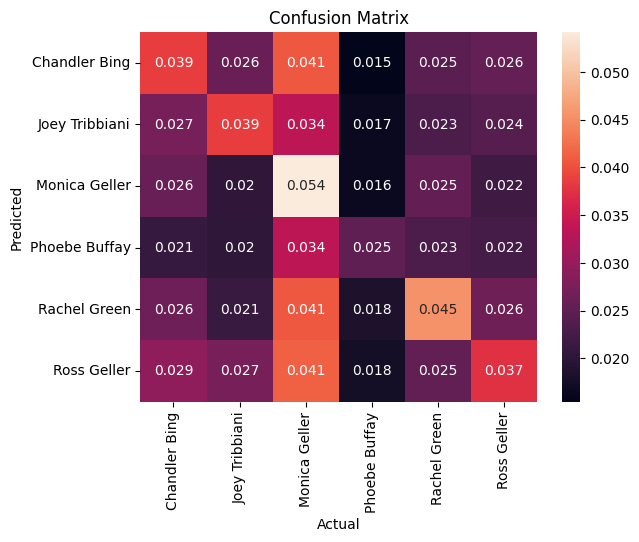

In [ ]:
# (A)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# (B)
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42).fit(X_train,y_train)

# (C)
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_pred, y_test), "/ Random:", 1/6) # 6 main char
# better the classifier one 

# (D)
cm = pd.DataFrame(confusion_matrix(y_test,y_pred,normalize='all'),columns=map_char_to_int, index=map_char_to_int)

# (E)
sns.heatmap(cm, annot=True, cbar=True)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')

# (F)
# - Monica 
# - Monica and Chandler
# - Phobe and Chandler

---

**2.3 —** **/Discuss:/** Last, you discuss the results obtained in **2.2** with a friend, who asks you some thought-provoking questions.

A. Your friend proposes that you should create a measure of similarity between two characters in a given episode in a more direct way than what you've done in **2.2**.  Propose (but do not implement) said similarity metric.

B. Your friend also suggests that your analysis might not truly capture how two characters differ. According to her, if people are in the same conversation, they might speak similarly simply because they are in the same social context. Propose (but do not implement) a way of creating a dataset where this confounder does not exist.

C. Last, your friend complains about how you present your (normalized) confusion matrix. According to her, from reading the cells alone, it is unclear if the fraction of occurrences is higher or lower than what a random classifier would yield. Propose (but do not implement) a way of modifying the confusion matrix to address her concern.


- A. cosine distance
- B. construct the IF-IDF on episode and conduct the analyszie per episode and the mean the scores
   OR construct the df wihtout only the main char conversation: we dont care about social context 
- C. substartc a random cm 

---